<a href="https://colab.research.google.com/github/dinindriati-gif/sarbagita-landcover-projection/blob/main/Dini_Indriati_Peta_Proyeksi_Tutupan_Lahan_Sarbagita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MOUNT GOOGLE DRIVE**

In [4]:
import os

In [5]:
# Membaca Penyimpanan Drive, setujui izin akses ketika muncul pop up perizinan
from google.colab import drive
drive.mount('/content/drive') # Penyimpanan di atur ke folder '/content/drive' (default)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Menentukan lokasi penyimpanan
loc = '/content/drive/MyDrive/ATRBPN'

In [8]:
# Mengubah ke penyimpanan yang sudah kita deifinisikan sebelumnya
os.chdir(loc)

# Cek lokasi penyimpanan apakah sudah sesuai dengan yang sudah kita tenetukan
print('Working Directory: ',os.getcwd())

Working Directory:  /content/drive/MyDrive/ATRBPN


**INSTAL LIBRARY**

In [9]:
# Instalasi Library
!pip install geopandas rasterio rioxarray openpyxl scikit-learn

In [10]:
# Import Library
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from shapely.geometry import Point
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

**TRAINING SAMPLE**

In [11]:
import geopandas as gpd
import numpy as np
import rasterio
from shapely.geometry import Point

# Pemetaan Kode & Nama Kelas yang Benar
CLASS_NAMES = {
    1: "Hutan / Vegetasi Lebat",  # Kode 1
    2: "Pertanian / Sawah",  # Kode 2
    3: "Lahan Terbuka / Semak Belukar",  # Kode 3
    4: "Lahan Terbangun / Permukiman",  # Kode 4
    5: "Badan Air / Perairan",  # Kode 5
}


def classify_rgb_correct(raster_path):
    with rasterio.open(raster_path) as src:
        r = src.read(1).astype(float)
        g = src.read(2).astype(float)
        b = src.read(3).astype(float)
        transform = src.transform
        crs = src.crs

    # Masking Latar Belakang / NoData Hitam
    valid = (r > 10) & (g > 10) & (b > 10)
    brightness = (r + g + b) / 3.0

    # Buat grid koordinat Y (baris) untuk membatasi area utara
    rows, cols = r.shape
    row_grid, _ = np.indices((rows, cols))

    # Masking Khusus Area Utara (35% bagian atas citra tempat danau berada)
    is_north_region = row_grid < (rows * 0.35)

    classified = np.zeros_like(r, dtype=np.uint8)

    classified = np.zeros_like(r, dtype=np.uint8)

    # Dapatkan dimensi raster untuk membuat mask wilayah utara
    rows, cols = r.shape
    # Buat mask untuk 35% wilayah bagian utara
    is_north_region = np.indices(r.shape)[0] < (rows * 0.35)

    # 1. Badan Air: Sangat Gelap DAN Kanal Biru LEBIH TINGGI dari Kanal Merah & Hijau
    # - Syarat Laut/Air Umum (Kondisi Awal yang Presisi)
    sea_water = valid & (brightness < 40) & (b > r) & (b >= g * 0.9)

    # - Syarat Danau Utara (Hanya berlaku di 35% wilayah bagian utara)
    #   Danau: Sangat pekat (brightness < 55), kanal R paling rendah, DAN bukan vegetasi pekat (G tidak mendominasi R secara ekstrem)
    lake_water = (
        valid
        & is_north_region
        & (brightness < 55)
        & (r < g)
        & (r < b)
        & (g < r * 1.25)  # Mencegah hutan pekat ikut terambil
    )

    water_mask = sea_water | lake_water
    classified[water_mask] = 5

    # 2. Hutan (Kode 1) -> Vegetasi Sangat Hijau & Agak Gelap (Di luar air)
    forest_mask = (
        valid
        & (~water_mask)
        & (g > r * 1.2)
        & (g > b * 1.15)
        & (brightness < 90)
    )
    classified[forest_mask] = 1

    # 3. Pertanian/Sawah (Kode 2) -> Hijau Terang/Sedang
    agri_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (g > r * 1.05)
        & (brightness >= 90)
    )
    classified[agri_mask] = 2

    # 4. Lahan Terbangun (Kode 4) -> Terang/Atap/Seng
    built_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (~agri_mask)
        & (brightness > 110)
        & (np.abs(r - g) < 25)
    )
    classified[built_mask] = 4

    # 5. Lahan Terbuka (Kode 3) -> Sisanya
    open_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (~agri_mask)
        & (~built_mask)
        & (classified == 0)
    )
    classified[open_mask] = 3

    return classified, transform, crs


# Eksekusi 2020 & 2023
class_2020, transform, crs = classify_rgb_correct("Sarbagita_2020.tif")
class_2023, _, _ = classify_rgb_correct("Sarbagita_2023.tif")

# Filter Stabil 2020-2023
mask_konsisten = (class_2020 == class_2023) & (class_2020 > 0)

# Stratified Sampling 100 Titik/Kelas
samples_per_class = 100
np.random.seed(42)

sample_ids, points, landcover_class, landcover_name = [], [], [], []
current_id = 1

for code, name in CLASS_NAMES.items():
    class_mask = mask_konsisten & (class_2020 == code)
    valid_y, valid_x = np.where(class_mask)

    if len(valid_y) > 0:
        n_take = min(samples_per_class, len(valid_y))
        chosen_indices = np.random.choice(
            len(valid_y), size=n_take, replace=False
        )

        for idx in chosen_indices:
            r_idx, c_idx = valid_y[idx], valid_x[idx]
            x, y = transform * (c_idx + 0.5, r_idx + 0.5)

            sample_ids.append(current_id)
            points.append(Point(x, y))
            landcover_class.append(code)
            landcover_name.append(name)
            current_id += 1

# Export Shapefile
output_shp = "training_sample_tutupan_lahan.shp"
gdf = gpd.GeoDataFrame(
    {"id": sample_ids, "class": landcover_class, "class_name": landcover_name},
    geometry=points,
    crs=crs,
)
gdf.to_file(output_shp)
print("SELESAI! File shapefile berhasil diperbaiki.")

SELESAI! File shapefile berhasil diperbaiki.


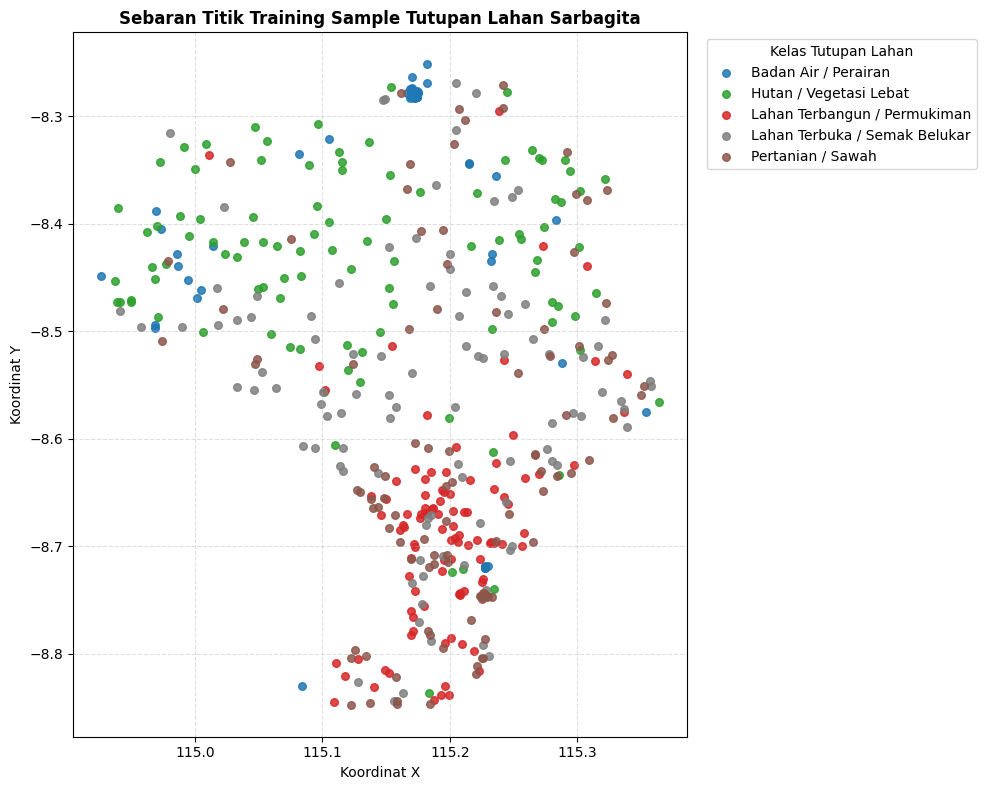

,Jumlah Sampel,count
0,Hutan / Vegetasi Lebat,100
1,Pertanian / Sawah,100
2,Lahan Terbuka / Semak Belukar,100
3,Lahan Terbangun / Permukiman,100
4,Badan Air / Perairan,100


In [12]:
import matplotlib.pyplot as plt

gdf_samples = gpd.read_file("training_sample_tutupan_lahan.shp")

color_dict = {
    "Hutan / Vegetasi Lebat": "#2ca02c",  # Hijau
    "Pertanian / Sawah": "#8c564b",  # Cokelat
    "Lahan Terbuka / Semak": "#bcbd22",  # Kuning
    "Lahan Terbangun / Permukiman": "#d62728",  # Merah
    "Badan Air / Perairan": "#1f77b4",  # Biru
}

fig, ax = plt.subplots(figsize=(10, 8))

for class_name, group in gdf_samples.groupby("class_name"):
    ax.scatter(
        group.geometry.x,
        group.geometry.y,
        label=class_name,
        color=color_dict.get(class_name, "#7f7f7f"),
        s=30,
        alpha=0.85,
    )

plt.title(
    "Sebaran Titik Training Sample Tutupan Lahan Sarbagita",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Koordinat X")
plt.ylabel("Koordinat Y")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(
    title="Kelas Tutupan Lahan",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

# Ringkasan jumlah per kelas
display(
    gdf_samples["class_name"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "Nama Kelas", "class_name": "Jumlah Sampel"})
)

**Peta klasifikasi tutupan lahan Sarbagita Tahun 2020 (raster/.tiff)**

In [67]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize
from scipy.ndimage import median_filter


def generate_landcover_2020_optimized(
    input_raster, lake_shp_path, output_raster
):
    print(
        f"Memproses klasifikasi 2020 (Optimasi Agri Mask): {input_raster}..."
    )

    with rasterio.open(input_raster) as src:
        r = src.read(1).astype(float)
        g = src.read(2).astype(float)
        b = src.read(3).astype(float)
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs

    valid = (r > 10) & (g > 10) & (b > 10)
    brightness = (r + g + b) / 3.0

    # 1. Integrasi SHP Danau Batur
    lake_gdf = gpd.read_file(lake_shp_path)
    if lake_gdf.crs != crs:
        lake_gdf = lake_gdf.to_crs(crs)

    lake_shapes = [(geom, 1) for geom in lake_gdf.geometry]
    lake_mask_from_shp = (
        rasterize(
            shapes=lake_shapes,
            out_shape=r.shape,
            transform=transform,
            fill=0,
            dtype=np.uint8,
        )
        == 1
    )

    classified = np.zeros_like(r, dtype=np.uint8)

    # A. BADAN AIR (Kode 5)
    sea_water = valid & (brightness < 40) & (b > r) & (b >= g * 0.9)
    lake_water = valid & lake_mask_from_shp
    water_mask = sea_water | lake_water
    classified[water_mask] = 5

    # B. HUTAN / VEGETASI LEBAT (Kode 1)
    # Hutan diposisikan memegang vegetasi hijau sangat lebat & agak gelap
    forest_mask = (
        valid
        & (~water_mask)
        & (g > r * 1.15)
        & (g > b * 1.10)
        & (brightness < 85)
    )
    classified[forest_mask] = 1

    # C. PERTANIAN / SAWAH (Kode 2) - Ditingkatkan fleksibilitas spektralnya
    # Menangkap vegetasi sedang (sawah/kebun) dengan rentang brightness lebih luas (70 - 165)
    agri_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (g >= r * 1.015)  # Rasio hijau dilonggarkan sedikit
        & (g >= b * 0.98)
        & (brightness >= 70)
        & (brightness <= 165)
    )
    classified[agri_mask] = 2

    # D. LAHAN TERBANGUN (Kode 4)
    built_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (~agri_mask)
        & (brightness > 95)
        & (np.abs(r - g) < 30)
    )
    classified[built_mask] = 4

    # E. LAHAN TERBUKA (Kode 3) - Menampung sisa area non-vegetasi/tanah
    open_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (~agri_mask)
        & (~built_mask)
        & (classified == 0)
    )
    classified[open_mask] = 3

    # =========================================================================
    # POST-PROCESSING: SPATIAL MEDIAN FILTERING (3x3)
    # =========================================================================
    print("Menerapkan Median Filter 3x3...")
    smoothed_classified = median_filter(classified, size=3)

    # Kunci ulang Badan Air agar tidak terpengaruh filter
    smoothed_classified[water_mask] = 5

    # Simpan Hasil Klasifikasi
    profile.update(
        dtype=rasterio.uint8, count=1, nodata=0, compress="lzw"
    )

    with rasterio.open(output_raster, "w", **profile) as dst:
        dst.write(smoothed_classified.astype(np.uint8), 1)

    print(f"BERHASIL! Hasil 2020 tersimpan di: {output_raster}\n")


# Eksekusi Klasifikasi 2020
generate_landcover_2020_optimized(
    "Sarbagita_2020.tif", "danau_batur.shp", "Sarbagita_2020_tutupan_lahan.tif"
)

Memproses klasifikasi 2020 (Optimasi Agri Mask): Sarbagita_2020.tif...
Menerapkan Median Filter 3x3...
BERHASIL! Hasil 2020 tersimpan di: Sarbagita_2020_tutupan_lahan.tif



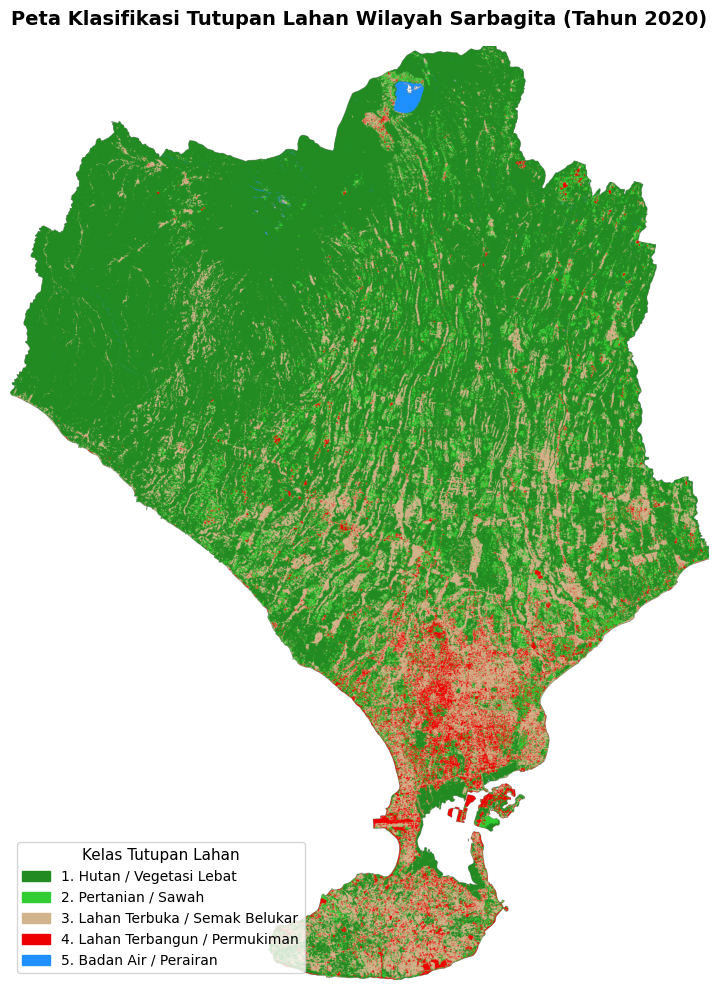

In [68]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import rasterio

# Pemetaan Warna dan Label Sesuai Kode Kelas
# 1: Hutan, 2: Pertanian, 3: Lahan Terbuka, 4: Lahan Terbangun, 5: Air
color_dict = {
    1: "#228B22",  # Hijau Tua (Hutan / Vegetasi Lebat)
    2: "#32CD32",  # Hijau Muda (Pertanian / Sawah)
    3: "#D2B48C",  # Cokelat Muda (Lahan Terbuka / Semak)
    4: "#EE0000",  # Merah (Lahan Terbangun / Permukiman)
    5: "#1E90FF",  # Biru (Badan Air / Perairan)
}

class_names = {
    1: "Hutan / Vegetasi Lebat",
    2: "Pertanian / Sawah",
    3: "Lahan Terbuka / Semak Belukar",
    4: "Lahan Terbangun / Permukiman",
    5: "Badan Air / Perairan",
}


def plot_landcover_map(raster_path, title):
    with rasterio.open(raster_path) as src:
        data = src.read(1)

    # Buat custom colormap untuk nilai 1-5 (nilai 0 / nodata transparan)
    cmap = ListedColormap(
        [color_dict[1], color_dict[2], color_dict[3], color_dict[4], color_dict[5]]
    )

    # Masking nilai 0 (NoData / Latar Belakang Hitam)
    data_masked = np.ma.masked_where(data == 0, data)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Tampilkan Raster (Index 1-5 disesuaikan ke vmin=1, vmax=5)
    im = ax.imshow(data_masked, cmap=cmap, vmin=1, vmax=5)

    # Buat Legenda Manual
    patches = [
        mpatches.Patch(color=color_dict[code], label=f"{code}. {class_names[code]}")
        for code in sorted(color_dict.keys())
    ]
    ax.legend(
        handles=patches,
        loc="lower left",
        title="Kelas Tutupan Lahan",
        fontsize=10,
        title_fontsize=11,
        frameon=True,
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")  # Sembunyikan sumbu koordinat piksel agar tampilan rapi

    plt.tight_layout()
    plt.show()

# Tampilkan Peta 2020
plot_landcover_map(
    "Sarbagita_2020_tutupan_lahan.tif",
    "Peta Klasifikasi Tutupan Lahan Wilayah Sarbagita (Tahun 2020)",
)

**Peta klasifikasi tutupan lahan Sarbagita Tahun 2023 (raster/.tiff)**

In [65]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize
from scipy.ndimage import median_filter


def generate_landcover_2023_optimized(
    input_raster, lake_shp_path, output_raster
):
    print(
        f"Memproses klasifikasi 2023 (Optimasi Agri Mask): {input_raster}..."
    )

    with rasterio.open(input_raster) as src:
        r = src.read(1).astype(float)
        g = src.read(2).astype(float)
        b = src.read(3).astype(float)
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs

    valid = (r > 10) & (g > 10) & (b > 10)
    brightness = (r + g + b) / 3.0

    lake_gdf = gpd.read_file(lake_shp_path)
    if lake_gdf.crs != crs:
        lake_gdf = lake_gdf.to_crs(crs)

    lake_shapes = [(geom, 1) for geom in lake_gdf.geometry]
    lake_mask_from_shp = (
        rasterize(
            shapes=lake_shapes,
            out_shape=r.shape,
            transform=transform,
            fill=0,
            dtype=np.uint8,
        )
        == 1
    )

    classified = np.zeros_like(r, dtype=np.uint8)

    # A. BADAN AIR (Kode 5)
    sea_water = valid & (brightness < 40) & (b > r) & (b >= g * 0.9)
    lake_water = valid & lake_mask_from_shp
    water_mask = sea_water | lake_water
    classified[water_mask] = 5

    # B. HUTAN / VEGETASI LEBAT (Kode 1)
    forest_mask = (
        valid
        & (~water_mask)
        & (g > r * 1.15)
        & (g > b * 1.10)
        & (brightness < 85)
    )
    classified[forest_mask] = 1

    # C. PERTANIAN / SAWAH (Kode 2)
    agri_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (g >= r * 1.015)
        & (g >= b * 0.98)
        & (brightness >= 70)
        & (brightness <= 165)
    )
    classified[agri_mask] = 2

    # D. LAHAN TERBANGUN (Kode 4)
    built_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (~agri_mask)
        & (brightness > 95)
        & (np.abs(r - g) < 30)
    )
    classified[built_mask] = 4

    # E. LAHAN TERBUKA (Kode 3)
    open_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (~agri_mask)
        & (~built_mask)
        & (classified == 0)
    )
    classified[open_mask] = 3

    # =========================================================================
    # POST-PROCESSING: SPATIAL MEDIAN FILTERING (3x3)
    # =========================================================================
    print("Menerapkan Median Filter 3x3...")
    smoothed_classified = median_filter(classified, size=3)

    # Kunci ulang Badan Air
    smoothed_classified[water_mask] = 5

    # Simpan Hasil Klasifikasi
    profile.update(
        dtype=rasterio.uint8, count=1, nodata=0, compress="lzw"
    )

    with rasterio.open(output_raster, "w", **profile) as dst:
        dst.write(smoothed_classified.astype(np.uint8), 1)

    print(f"BERHASIL! Hasil 2023 tersimpan di: {output_raster}\n")


# Eksekusi Klasifikasi 2023
generate_landcover_2023_optimized(
    "Sarbagita_2023.tif", "danau_batur.shp", "Sarbagita_2023_tutupan_lahan.tif"
)

Memproses klasifikasi 2023 (Optimasi Agri Mask): Sarbagita_2023.tif...
Menerapkan Median Filter 3x3...
BERHASIL! Hasil 2023 tersimpan di: Sarbagita_2023_tutupan_lahan.tif



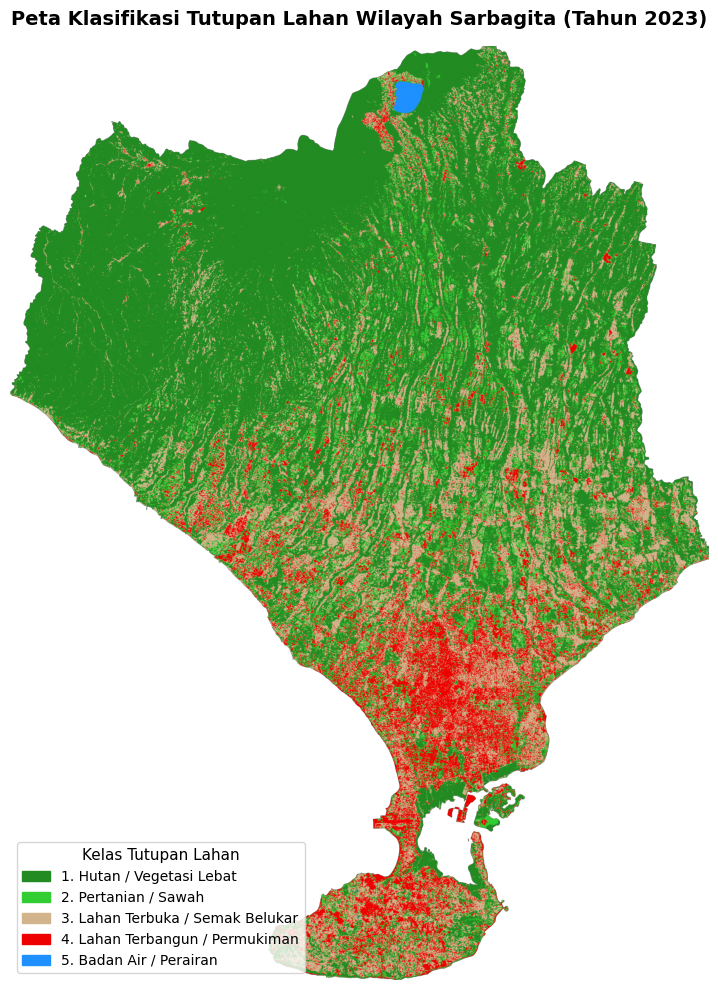

In [66]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import rasterio

# Pemetaan Warna dan Label Sesuai Kode Kelas
# 1: Hutan, 2: Pertanian, 3: Lahan Terbuka, 4: Lahan Terbangun, 5: Air
color_dict = {
    1: "#228B22",  # Hijau Tua (Hutan / Vegetasi Lebat)
    2: "#32CD32",  # Hijau Muda (Pertanian / Sawah)
    3: "#D2B48C",  # Cokelat Muda (Lahan Terbuka / Semak)
    4: "#EE0000",  # Merah (Lahan Terbangun / Permukiman)
    5: "#1E90FF",  # Biru (Badan Air / Perairan)
}

class_names = {
    1: "Hutan / Vegetasi Lebat",
    2: "Pertanian / Sawah",
    3: "Lahan Terbuka / Semak Belukar",
    4: "Lahan Terbangun / Permukiman",
    5: "Badan Air / Perairan",
}


def plot_landcover_map(raster_path, title):
    with rasterio.open(raster_path) as src:
        data = src.read(1)

    # Buat custom colormap untuk nilai 1-5 (nilai 0 / nodata transparan)
    cmap = ListedColormap(
        [color_dict[1], color_dict[2], color_dict[3], color_dict[4], color_dict[5]]
    )

    # Masking nilai 0 (NoData / Latar Belakang Hitam)
    data_masked = np.ma.masked_where(data == 0, data)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Tampilkan Raster (Index 1-5 disesuaikan ke vmin=1, vmax=5)
    im = ax.imshow(data_masked, cmap=cmap, vmin=1, vmax=5)

    # Buat Legenda Manual
    patches = [
        mpatches.Patch(color=color_dict[code], label=f"{code}. {class_names[code]}")
        for code in sorted(color_dict.keys())
    ]
    ax.legend(
        handles=patches,
        loc="lower left",
        title="Kelas Tutupan Lahan",
        fontsize=10,
        title_fontsize=11,
        frameon=True,
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")  # Sembunyikan sumbu koordinat piksel agar tampilan rapi

    plt.tight_layout()
    plt.show()

# Tampilkan Peta 2023
plot_landcover_map(
    "Sarbagita_2023_tutupan_lahan.tif",
    "Peta Klasifikasi Tutupan Lahan Wilayah Sarbagita (Tahun 2023)",
)

**Peta Proyeksi Tutupan Lahan Sarbagita Tahun 2026**

In [69]:
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier

print("1. Memuat raster 2020 & 2023...")
with rasterio.open("Sarbagita_2020_tutupan_lahan.tif") as src20:
    lc_2020 = src20.read(1)
    profile = src20.profile.copy()

with rasterio.open("Sarbagita_2023_tutupan_lahan.tif") as src23:
    lc_2023 = src23.read(1)

# Masking piksel valid (abaikan background / NoData = 0)
valid_mask = (lc_2020 > 0) & (lc_2023 > 0)
water_restriction = lc_2023 == 5

# 2. Driving Factors (Proxy Spasial & Proksimitas)
rows, cols = lc_2020.shape
row_grid, col_grid = np.indices((rows, cols))

y_factor = (row_grid / float(rows)).astype(np.float32)
x_factor = (col_grid / float(cols)).astype(np.float32)
center_y, center_x = rows // 2, cols // 2
dist_center = (
    np.sqrt((row_grid - center_y) ** 2 + (col_grid - center_x) ** 2)
    / np.sqrt(rows**2 + cols**2)
).astype(np.float32)

# Sub-sampling data latih (Ambil max 100.000 piksel acak agar sangat cepat)
valid_indices = np.argwhere(valid_mask)
n_samples = min(100000, len(valid_indices))
np.random.seed(42)
sample_idx = valid_indices[
    np.random.choice(len(valid_indices), n_samples, replace=False)
]

r_idx, c_idx = sample_idx[:, 0], sample_idx[:, 1]

X_train_sub = np.column_stack(
    [
        lc_2020[r_idx, c_idx],
        y_factor[r_idx, c_idx],
        x_factor[r_idx, c_idx],
        dist_center[r_idx, c_idx],
    ]
)
y_train_sub = lc_2023[r_idx, c_idx]

# 3. Melatih Model (Sangat Cepat karena Sub-sampling)
print("2. Melatih model Random Forest...")
model = RandomForestClassifier(
    n_estimators=50, max_depth=15, random_state=42, n_jobs=-1
)
model.fit(X_train_sub, y_train_sub)

# 4. Prediksi Proyeksi 2026 secara Bertahap (Chunk-by-chunk agar RAM hemat)
print("3. Memprediksi tutupan lahan 2026...")
lc_2026_matrix = np.zeros_like(lc_2020, dtype=np.uint8)

# Memproses per 500 baris agar tidak membebani memori
chunk_size = 500
for i in range(0, rows, chunk_size):
    row_end = min(i + chunk_size, rows)
    chunk_mask = valid_mask[i:row_end, :]

    if not np.any(chunk_mask):
        continue

    X_chunk = np.column_stack(
        [
            lc_2023[i:row_end, :][chunk_mask],
            y_factor[i:row_end, :][chunk_mask],
            x_factor[i:row_end, :][chunk_mask],
            dist_center[i:row_end, :][chunk_mask],
        ]
    )

    pred_chunk = model.predict(X_chunk)
    lc_2026_matrix[i:row_end, :][chunk_mask] = pred_chunk

# Menerapkan Restricting Factor (Badan Air dikunci)
lc_2026_matrix[water_restriction] = 5

# 5. Export GeoTIFF
profile.update(dtype=rasterio.uint8, count=1, nodata=0, compress="lzw")
output_proj_path = "Sarbagita_2026_proyeksi_tutupan_lahan.tif"

with rasterio.open(output_proj_path, "w", **profile) as dst:
    dst.write(lc_2026_matrix, 1)

print(f"SELESAI! [4d] Peta Proyeksi 2026 tersimpan di: {output_proj_path}")

1. Memuat raster 2020 & 2023...
2. Melatih model Random Forest...
3. Memprediksi tutupan lahan 2026...
SELESAI! [4d] Peta Proyeksi 2026 tersimpan di: Sarbagita_2026_proyeksi_tutupan_lahan.tif


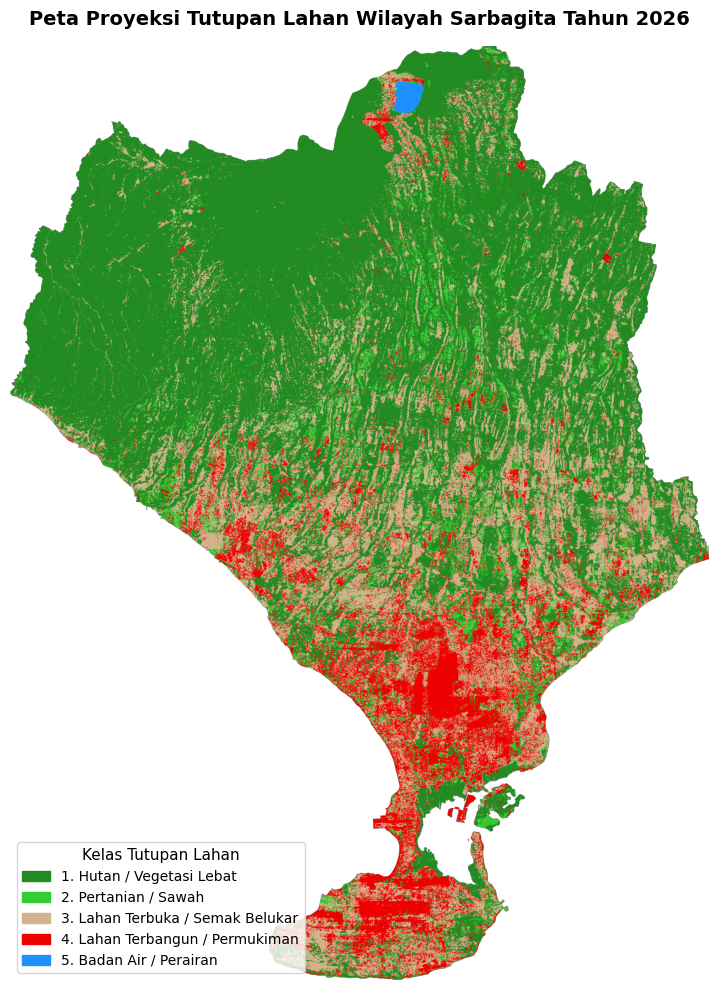

In [70]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import rasterio

# Pemetaan Warna dan Label Sesuai Kode Kelas
# 1: Hutan, 2: Pertanian, 3: Lahan Terbuka, 4: Lahan Terbangun, 5: Air
color_dict = {
    1: "#228B22",  # Hijau Tua (Hutan / Vegetasi Lebat)
    2: "#32CD32",  # Hijau Muda (Pertanian / Sawah)
    3: "#D2B48C",  # Cokelat Muda (Lahan Terbuka / Semak)
    4: "#EE0000",  # Merah (Lahan Terbangun / Permukiman)
    5: "#1E90FF",  # Biru (Badan Air / Perairan)
}

class_names = {
    1: "Hutan / Vegetasi Lebat",
    2: "Pertanian / Sawah",
    3: "Lahan Terbuka / Semak Belukar",
    4: "Lahan Terbangun / Permukiman",
    5: "Badan Air / Perairan",
}


def plot_landcover_map(raster_path, title):
    with rasterio.open(raster_path) as src:
        data = src.read(1)

    # Buat custom colormap untuk nilai 1-5 (nilai 0 / nodata transparan)
    cmap = ListedColormap(
        [color_dict[1], color_dict[2], color_dict[3], color_dict[4], color_dict[5]]
    )

    # Masking nilai 0 (NoData / Latar Belakang Hitam)
    data_masked = np.ma.masked_where(data == 0, data)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Tampilkan Raster (Index 1-5 disesuaikan ke vmin=1, vmax=5)
    im = ax.imshow(data_masked, cmap=cmap, vmin=1, vmax=5)

    # Buat Legenda Manual
    patches = [
        mpatches.Patch(color=color_dict[code], label=f"{code}. {class_names[code]}")
        for code in sorted(color_dict.keys())
    ]
    ax.legend(
        handles=patches,
        loc="lower left",
        title="Kelas Tutupan Lahan",
        fontsize=10,
        title_fontsize=11,
        frameon=True,
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")  # Sembunyikan sumbu koordinat piksel agar tampilan rapi

    plt.tight_layout()
    plt.show()

# Tampilkan Peta 2023
plot_landcover_map(
    "Sarbagita_2026_proyeksi_tutupan_lahan.tif",
    "Peta Proyeksi Tutupan Lahan Wilayah Sarbagita Tahun 2026",
)

**Tabulasi Hasil Uji Akurasi Validitas Model**

In [71]:
import numpy as np
import pandas as pd
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from sklearn.model_selection import train_test_split

print("1. Memuat raster 2020 & 2023...")
with rasterio.open("Sarbagita_2020_tutupan_lahan.tif") as src20:
    lc_2020 = src20.read(1)

with rasterio.open("Sarbagita_2023_tutupan_lahan.tif") as src23:
    lc_2023 = src23.read(1)

valid_mask = (lc_2020 > 0) & (lc_2023 > 0)

# Driving Factors
rows, cols = lc_2020.shape
row_grid, col_grid = np.indices((rows, cols))
y_factor = (row_grid / float(rows)).astype(np.float32)
x_factor = (col_grid / float(cols)).astype(np.float32)
center_y, center_x = rows // 2, cols // 2
dist_center = (
    np.sqrt((row_grid - center_y) ** 2 + (col_grid - center_x) ** 2)
    / np.sqrt(rows**2 + cols**2)
).astype(np.float32)

# Sub-sampling
valid_indices = np.argwhere(valid_mask)
n_samples = min(150000, len(valid_indices))
np.random.seed(42)
sample_idx = valid_indices[
    np.random.choice(len(valid_indices), n_samples, replace=False)
]

r_idx, c_idx = sample_idx[:, 0], sample_idx[:, 1]

X_sub = np.column_stack(
    [
        lc_2020[r_idx, c_idx],
        y_factor[r_idx, c_idx],
        x_factor[r_idx, c_idx],
        dist_center[r_idx, c_idx],
    ]
)
y_sub = lc_2023[r_idx, c_idx]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

# Training Model
print("2. Melatih model & mengevaluasi metrik akurasi...")
model = RandomForestClassifier(
    n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Confusion Matrix
all_labels = [1, 2, 3, 4, 5]
cm = confusion_matrix(y_test, y_pred, labels=all_labels)
kappa = cohen_kappa_score(y_test, y_pred, labels=all_labels)
overall_accuracy = np.trace(cm) / float(np.sum(cm))

# Handling pembagian nol
with np.errstate(divide="ignore", invalid="ignore"):
    col_sum = np.sum(cm, axis=0)
    row_sum = np.sum(cm, axis=1)

    producer_accuracy = np.where(col_sum > 0, np.diag(cm) / col_sum, 0.0)
    user_accuracy = np.where(row_sum > 0, np.diag(cm) / row_sum, 0.0)

class_names = [
    "1. Hutan / Vegetasi Lebat",
    "2. Pertanian / Sawah",
    "3. Lahan Terbuka / Semak",
    "4. Lahan Terbangun / Permukiman",
    "5. Badan Air / Perairan",
]

# Tabulasi Kelas
accuracy_df = pd.DataFrame(
    {
        "Kelas Tutupan Lahan": class_names,
        "Producer's Accuracy (%)": np.round(producer_accuracy * 100, 2),
        "User's Accuracy (%)": np.round(user_accuracy * 100, 2),
    }
)

# Format Ekspor CSV & Excel
accuracy_df.to_csv("tabulasi_uji_akurasi_sarbagita.csv", index=False)
accuracy_df.to_excel("tabulasi_uji_akurasi_sarbagita.xlsx", index=False)

# Cetak Tampilan yang Jelas & Terpisah
print("\n" + "=" * 60)
print("TABULASI UJI AKURASI VALIDITAS PREDIKSI TUTUPAN LAHAN")
print("=" * 60)
print(accuracy_df.to_string(index=False))
print("-" * 60)
print(f"Overall Accuracy    : {overall_accuracy * 100:.2f}%")
print(f"Cohen's Kappa Index : {kappa:.4f}")
print("=" * 60)
print(
    "\nBERHASIL! [4e] File tabulasi tersimpan di: tabulasi_uji_akurasi_sarbagita.csv & .xlsx"
)

1. Memuat raster 2020 & 2023...
2. Melatih model & mengevaluasi metrik akurasi...

TABULASI UJI AKURASI VALIDITAS PREDIKSI TUTUPAN LAHAN
            Kelas Tutupan Lahan  Producer's Accuracy (%)  User's Accuracy (%)
      1. Hutan / Vegetasi Lebat                    83.53                92.84
           2. Pertanian / Sawah                    38.51                22.08
       3. Lahan Terbuka / Semak                    61.89                61.08
4. Lahan Terbangun / Permukiman                    63.32                54.10
        5. Badan Air / Perairan                   100.00                95.31
------------------------------------------------------------
Overall Accuracy    : 74.60%
Cohen's Kappa Index : 0.5531

BERHASIL! [4e] File tabulasi tersimpan di: tabulasi_uji_akurasi_sarbagita.csv & .xlsx
